In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import os
import time
import warnings
import json
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ============================================================
# CELL 2: FIND CSV FILES IN KAGGLE INPUT
# ============================================================

csv_files = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(
                os.path.join(root, file)
            )

print("CSV files found:\n")

for i, file in enumerate(csv_files):
    print(f"{i}: {file}")

CSV files found:

0: /kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv


In [3]:
# ============================================================
# CELL 3: FIND AND LOAD THE CORRECT DATASET
# ============================================================

required_columns = {
    "training_duration",
    "training_intensity",
    "training_load",
    "heart_rate",
    "sleep_quality",
    "recovery_score",
    "stress_level",
    "fatigue_index"
}

selected_file = None

for file in csv_files:

    try:

        temp_df = pd.read_csv(
            file,
            nrows=5
        )

        if required_columns.issubset(
            set(temp_df.columns)
        ):

            selected_file = file
            break

    except Exception:
        continue


if selected_file is None:

    raise FileNotFoundError(
        "Could not find a CSV containing all required columns."
    )


print("Selected dataset:")
print(selected_file)

df = pd.read_csv(selected_file)

print("\nDataset loaded successfully!")

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Selected dataset:
/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv

Dataset loaded successfully!

Dataset shape:
(15420, 29)

Columns:
['athlete_id', 'heart_rate', 'body_temperature', 'hydration_level', 'sleep_quality', 'recovery_score', 'stress_level', 'muscle_activity', 'joint_angles', 'gait_speed', 'cadence', 'step_count', 'jump_height', 'ground_reaction_force', 'range_of_motion', 'ambient_temperature', 'humidity', 'altitude', 'playing_surface', 'training_intensity', 'training_duration', 'training_load', 'fatigue_index', 'injury_occurred', 'session_id', 'sport_type', 'gender', 'age', 'bmi']


In [4]:
# ============================================================
# CELL 4: DATASET INSPECTION
# ============================================================

print("First 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

First 5 rows:


,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,sport_type,gender,age,bmi
0,1,NaN,37.048668,76.481477,5.466370,77.899691,0.375825,10.000000,126.480118,2.654327,...,5.678475,79.106564,548.417962,45.028687,0,1,Basketball,Female,18,25.105748
1,1,40.000000,36.929536,72.363938,6.899090,74.845323,0.279165,310.293156,157.631630,3.431107,...,NaN,116.954654,538.043815,42.254717,2,2,Basketball,Female,18,25.105748
2,1,76.174609,36.334841,100.000000,9.574152,83.538316,0.334061,158.659094,81.766287,0.800000,...,6.643242,96.354742,647.784339,61.870056,0,3,Basketball,Female,18,25.105748
3,1,100.543724,37.244474,86.172473,7.614297,79.966618,0.218766,107.079298,113.023701,1.713869,...,6.194427,97.619130,336.553431,50.268845,0,4,Basketball,Female,18,25.105748
4,1,78.001235,36.510766,83.195889,5.631979,56.945979,0.484086,164.347133,112.814695,2.154233,...,5.835804,83.155527,496.076352,29.233575,2,5,Basketball,Female,18,25.105748



Dataset shape:
(15420, 29)

Data types:


athlete_id                 int64
heart_rate               float64
body_temperature         float64
hydration_level          float64
sleep_quality            float64
recovery_score           float64
stress_level             float64
muscle_activity          float64
joint_angles             float64
gait_speed               float64
cadence                  float64
step_count                 int64
jump_height              float64
ground_reaction_force    float64
range_of_motion          float64
ambient_temperature      float64
humidity                 float64
altitude                 float64
playing_surface            int64
training_intensity       float64
training_duration        float64
training_load            float64
fatigue_index            float64
injury_occurred            int64
session_id                 int64
sport_type                object
gender                    object
age                        int64
bmi                      float64
dtype: object


Missing values:


athlete_id                 0
heart_rate               354
body_temperature           0
hydration_level          385
sleep_quality            493
recovery_score             0
stress_level               0
muscle_activity          570
joint_angles               0
gait_speed               431
cadence                    0
step_count                 0
jump_height                0
ground_reaction_force      0
range_of_motion            0
ambient_temperature        0
humidity                   0
altitude                   0
playing_surface            0
training_intensity       632
training_duration          0
training_load              0
fatigue_index              0
injury_occurred            0
session_id                 0
sport_type                 0
gender                     0
age                        0
bmi                        0
dtype: int64

In [5]:
# ============================================================
# CELL 5: STATISTICAL SUMMARY
# ============================================================

display(
    df.describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
athlete_id,15420.0,NaN,NaN,NaN,78.547601,45.070131,1.0,39.0,79.0,118.0,156.0
heart_rate,15066.0,NaN,NaN,NaN,72.688277,17.758991,40.0,60.097967,72.304051,84.812895,159.270125
body_temperature,15420.0,NaN,NaN,NaN,37.106443,0.594843,35.8,36.698612,37.10709,37.512165,39.2
hydration_level,15035.0,NaN,NaN,NaN,78.036991,11.848363,45.0,69.879145,78.165927,86.49844,100.0
sleep_quality,14927.0,NaN,NaN,NaN,5.817429,1.814602,1.155807,4.510581,5.75565,7.068894,10.0
recovery_score,15420.0,NaN,NaN,NaN,55.20222,17.326338,8.902584,42.321722,54.421403,67.37569,98.0
stress_level,15420.0,NaN,NaN,NaN,0.422916,0.173425,0.1,0.300472,0.421168,0.543678,0.95
muscle_activity,14850.0,NaN,NaN,NaN,247.724105,126.930007,10.0,159.150375,245.496682,334.039698,722.542819
joint_angles,15420.0,NaN,NaN,NaN,112.464607,30.367148,45.0,91.437246,112.548535,133.96007,175.0
gait_speed,14989.0,NaN,NaN,NaN,1.864699,0.603927,0.8,1.430372,1.854269,2.281691,3.5


In [6]:
# ============================================================
# CELL 6: SELECT ONLY THE 7 REQUIRED FACTORS
# ============================================================

FEATURES = [
    "training_duration",
    "training_intensity",
    "training_load",
    "heart_rate",
    "sleep_quality",
    "recovery_score",
    "stress_level"
]

TARGET = "fatigue_index"

IDENTIFIERS = [
    "athlete_id",
    "session_id"
]

# Check required columns
missing_columns = [
    col
    for col in FEATURES + [TARGET]
    if col not in df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


model_df = df[
    FEATURES + [TARGET]
].copy()


print("==========================================")
print("FEATURES USED BY MODEL")
print("==========================================")

for feature in FEATURES:
    print("✓", feature)


print("\nTARGET:")
print("✓ fatigue_index")


print("\nIDENTIFIERS:")
for identifier in IDENTIFIERS:

    if identifier in df.columns:
        print("✗", identifier, "→ NOT USED")


print("\nFinal dataframe shape:")
print(model_df.shape)

FEATURES USED BY MODEL
✓ training_duration
✓ training_intensity
✓ training_load
✓ heart_rate
✓ sleep_quality
✓ recovery_score
✓ stress_level

TARGET:
✓ fatigue_index

IDENTIFIERS:
✗ athlete_id → NOT USED
✗ session_id → NOT USED

Final dataframe shape:
(15420, 8)


Fatigue Index Statistics:


count    15420.000000
mean        59.698315
std         25.196238
min         15.000000
25%         41.717110
50%         57.340187
75%         75.186924
max        270.193219
Name: fatigue_index, dtype: float64


Missing fatigue_index values: 0


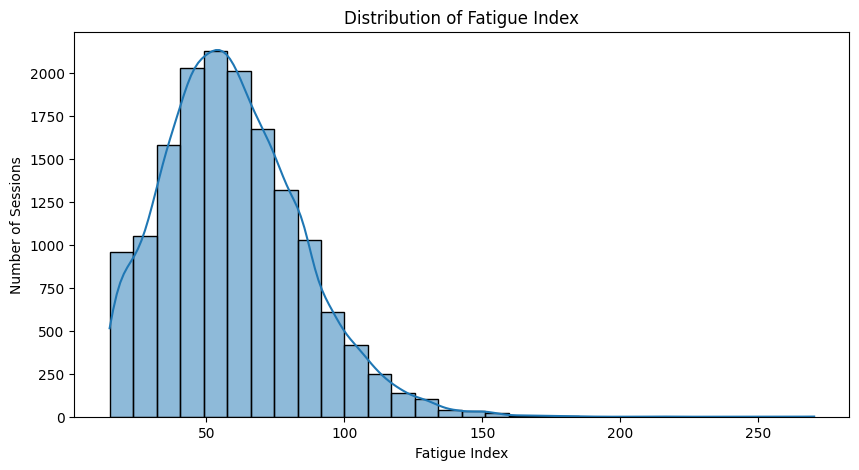

In [7]:
# ============================================================
# CELL 7: FATIGUE INDEX INSPECTION
# ============================================================

print("Fatigue Index Statistics:")

display(
    model_df[TARGET].describe()
)

print(
    "\nMissing fatigue_index values:",
    model_df[TARGET].isnull().sum()
)

plt.figure(figsize=(10, 5))

sns.histplot(
    model_df[TARGET].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Fatigue Index")
plt.xlabel("Fatigue Index")
plt.ylabel("Number of Sessions")

plt.show()

In [8]:
# ============================================================
# CELL 8: REMOVE MISSING TARGET VALUES
# ============================================================

before_rows = len(model_df)

model_df = model_df.dropna(
    subset=[TARGET]
).copy()

after_rows = len(model_df)

print("Rows before removing missing target:")
print(before_rows)

print("\nRows after removing missing target:")
print(after_rows)

print("\nRows removed:")
print(before_rows - after_rows)

Rows before removing missing target:
15420

Rows after removing missing target:
15420

Rows removed:
0


In [9]:
# ============================================================
# CELL 9: CREATE FATIGUE CLASSES
# ============================================================

q1 = model_df[TARGET].quantile(1/3)
q2 = model_df[TARGET].quantile(2/3)

print("Fatigue class thresholds:")
print("Q1:", q1)
print("Q2:", q2)


def create_fatigue_class(value):

    if value <= q1:
        return "Low"

    elif value <= q2:
        return "Moderate"

    else:
        return "High"


model_df["fatigue_class"] = (
    model_df[TARGET]
    .apply(create_fatigue_class)
)


print("\nFatigue class distribution:")

display(
    model_df["fatigue_class"]
    .value_counts()
)


print("\nFatigue class percentage:")

display(
    model_df["fatigue_class"]
    .value_counts(
        normalize=True
    ).mul(100).round(2)
)

Fatigue class thresholds:
Q1: 47.066454423822
Q2: 68.56416107512673

Fatigue class distribution:


fatigue_class
Low         5140
Moderate    5140
High        5140
Name: count, dtype: int64


Fatigue class percentage:


fatigue_class
Low         33.33
Moderate    33.33
High        33.33
Name: proportion, dtype: float64

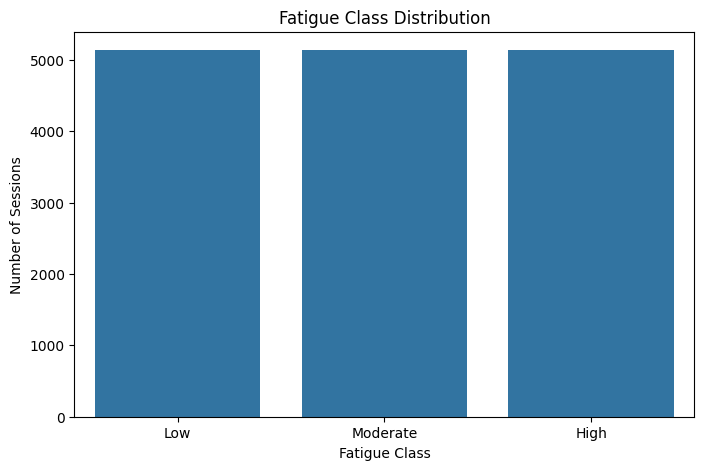

In [10]:
# ============================================================
# CELL 10: FATIGUE CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=model_df,
    x="fatigue_class",
    order=[
        "Low",
        "Moderate",
        "High"
    ]
)

plt.title("Fatigue Class Distribution")
plt.xlabel("Fatigue Class")
plt.ylabel("Number of Sessions")

plt.show()

In [11]:
# ============================================================
# CELL 11: ENCODE TARGET CLASSES
# ============================================================

class_mapping = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

reverse_mapping = {
    0: "Low",
    1: "Moderate",
    2: "High"
}


model_df["fatigue_class_encoded"] = (
    model_df["fatigue_class"]
    .map(class_mapping)
)


print("Class mapping:")

for name, number in class_mapping.items():
    print(f"{name} → {number}")


print("\nEncoded class distribution:")

display(
    model_df[
        "fatigue_class_encoded"
    ].value_counts().sort_index()
)

Class mapping:
Low → 0
Moderate → 1
High → 2

Encoded class distribution:


fatigue_class_encoded
0    5140
1    5140
2    5140
Name: count, dtype: int64

In [12]:
# ============================================================
# CELL 12: CREATE X AND y
# ============================================================

X = model_df[
    FEATURES
].copy()

y = model_df[
    "fatigue_class_encoded"
].copy()


print("X shape:")
print(X.shape)

print("\ny shape:")
print(y.shape)


print("\nFeatures used:")

for feature in X.columns:
    print("✓", feature)


print("\nTarget classes:")
print(sorted(y.unique()))

X shape:
(15420, 7)

y shape:
(15420,)

Features used:
✓ training_duration
✓ training_intensity
✓ training_load
✓ heart_rate
✓ sleep_quality
✓ recovery_score
✓ stress_level

Target classes:
[np.int64(0), np.int64(1), np.int64(2)]


In [13]:
# ============================================================
# CELL 13: CHECK FEATURE MISSING VALUES
# ============================================================

print("Missing values in model features:")

display(
    X.isnull().sum()
)

Missing values in model features:


training_duration       0
training_intensity    632
training_load           0
heart_rate            354
sleep_quality         493
recovery_score          0
stress_level            0
dtype: int64

In [14]:
# ============================================================
# CELL 14: TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training samples:")
print(len(X_train))

print("\nTesting samples:")
print(len(X_test))


print("\nTraining class distribution:")

display(
    y_train.value_counts()
    .sort_index()
)


print("\nTesting class distribution:")

display(
    y_test.value_counts()
    .sort_index()
)

Training samples:
12336

Testing samples:
3084

Training class distribution:


fatigue_class_encoded
0    4112
1    4112
2    4112
Name: count, dtype: int64


Testing class distribution:


fatigue_class_encoded
0    1028
1    1028
2    1028
Name: count, dtype: int64

In [15]:
# ============================================================
# CELL 15: MISSING VALUE IMPUTATION
# ============================================================

imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed = imputer.fit_transform(
    X_train
)

X_test_imputed = imputer.transform(
    X_test
)


print("Missing values handled successfully.")

print(
    "Training shape:",
    X_train_imputed.shape
)

print(
    "Testing shape:",
    X_test_imputed.shape
)

Missing values handled successfully.
Training shape: (12336, 7)
Testing shape: (3084, 7)


In [16]:
# ============================================================
# CELL 16: FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_imputed
)

X_test_scaled = scaler.transform(
    X_test_imputed
)


print("Feature scaling completed.")

print(
    "Training scaled shape:",
    X_train_scaled.shape
)

print(
    "Testing scaled shape:",
    X_test_scaled.shape
)

Feature scaling completed.
Training scaled shape: (12336, 7)
Testing scaled shape: (3084, 7)


In [17]:
# ============================================================
# CELL 17: CREATE LOGISTIC REGRESSION MODEL
# ============================================================

classifier = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",
    random_state=42,
    shuffle=True,
    max_iter=1,
    tol=None
)


print("Model created successfully.")

print("\nModel:")
print("Logistic Regression")

print("\nTraining method:")
print("Stochastic Gradient Descent")

print("\nTotal epochs:")
print("50")

Model created successfully.

Model:
Logistic Regression

Training method:
Stochastic Gradient Descent

Total epochs:
50


In [20]:
# ============================================================
# CELL 18: LOGISTIC REGRESSION
# 50 EPOCHS + MINI-BATCH TRAINING + TIME
# ============================================================

import numpy as np
import pandas as pd
import time

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.01

print("Starting training...")
print(f"Epochs: {EPOCHS}")
print(f"Training samples: {len(X_train_scaled)}")
print(f"Batch size: {BATCH_SIZE}")
print("Model: Logistic Regression")
print("Training method: Mini-Batch Gradient Descent")
print("=" * 60)


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

X_train_np = np.asarray(
    X_train_scaled,
    dtype=np.float64
)

y_train_np = np.asarray(
    y_train,
    dtype=np.int64
)


n_samples = len(X_train_np)
n_features = X_train_np.shape[1]

n_classes = 3


# ------------------------------------------------------------
# ONE-HOT ENCODE TARGET
# ------------------------------------------------------------

y_onehot = np.zeros(
    (n_samples, n_classes)
)

y_onehot[
    np.arange(n_samples),
    y_train_np
] = 1


# ------------------------------------------------------------
# INITIALIZE WEIGHTS
# ------------------------------------------------------------

np.random.seed(42)

weights = np.zeros(
    (n_features, n_classes)
)

bias = np.zeros(
    n_classes
)


# ------------------------------------------------------------
# SOFTMAX FUNCTION
# ------------------------------------------------------------

def softmax(z):

    z = z - np.max(
        z,
        axis=1,
        keepdims=True
    )

    exp_z = np.exp(z)

    return (
        exp_z /
        np.sum(
            exp_z,
            axis=1,
            keepdims=True
        )
    )


# ------------------------------------------------------------
# CROSS-ENTROPY LOSS
# ------------------------------------------------------------

def cross_entropy_loss(
    y_true,
    y_pred
):

    epsilon = 1e-15

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        np.sum(
            y_true * np.log(y_pred),
            axis=1
        )
    )

    return loss


# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------

epoch_history = []

training_start = time.perf_counter()


for epoch in range(EPOCHS):

    epoch_start = time.perf_counter()

    # Shuffle training data
    indices = np.random.permutation(
        n_samples
    )

    X_shuffled = X_train_np[
        indices
    ]

    y_shuffled = y_onehot[
        indices
    ]


    # Number of batches
    n_batches = int(
        np.ceil(
            n_samples / BATCH_SIZE
        )
    )


    batch_losses = []


    # --------------------------------------------------------
    # MINI-BATCH TRAINING
    # --------------------------------------------------------

    for batch_number in range(
        n_batches
    ):

        start = (
            batch_number *
            BATCH_SIZE
        )

        end = min(
            start + BATCH_SIZE,
            n_samples
        )


        X_batch = X_shuffled[
            start:end
        ]

        y_batch = y_shuffled[
            start:end
        ]


        # Forward pass
        logits = (
            X_batch @ weights
            + bias
        )


        probabilities = softmax(
            logits
        )


        # Calculate loss
        loss = cross_entropy_loss(
            y_batch,
            probabilities
        )

        batch_losses.append(
            loss
        )


        # ----------------------------------------------------
        # GRADIENT CALCULATION
        # ----------------------------------------------------

        error = (
            probabilities -
            y_batch
        )


        dw = (
            X_batch.T @ error
        ) / len(X_batch)


        db = np.mean(
            error,
            axis=0
        )


        # ----------------------------------------------------
        # UPDATE PARAMETERS
        # ----------------------------------------------------

        weights -= (
            LEARNING_RATE * dw
        )

        bias -= (
            LEARNING_RATE * db
        )


        # ----------------------------------------------------
        # PRINT EVERY 50 BATCHES
        # ----------------------------------------------------

        if (
            (batch_number + 1) % 50 == 0
            or
            batch_number + 1 == n_batches
        ):

            print(
                f"Epoch [{epoch + 1}/{EPOCHS}] "
                f"Batch [{batch_number + 1}/{n_batches}] "
                f"Loss: {loss:.4f}"
            )


    # --------------------------------------------------------
    # END OF EPOCH
    # --------------------------------------------------------

    epoch_end = time.perf_counter()

    epoch_time = (
        epoch_end -
        epoch_start
    )

    average_loss = np.mean(
        batch_losses
    )


    # --------------------------------------------------------
    # CALCULATE TRAINING ACCURACY
    # --------------------------------------------------------

    train_logits = (
        X_train_np @ weights
        + bias
    )

    train_probabilities = softmax(
        train_logits
    )

    train_predictions = np.argmax(
        train_probabilities,
        axis=1
    )


    train_epoch_accuracy = (
        np.mean(
            train_predictions ==
            y_train_np
        )
    )


    # Save epoch information

    epoch_history.append({

        "Epoch":
            epoch + 1,

        "Average_Loss":
            average_loss,

        "Training_Accuracy":
            train_epoch_accuracy,

        "Epoch_Time_Seconds":
            epoch_time,

        "Epoch_Time_Minutes":
            epoch_time / 60

    })


    # --------------------------------------------------------
    # EPOCH SUMMARY
    # --------------------------------------------------------

    print()
    print("-" * 60)

    print(
        f"Epoch {epoch + 1} completed"
    )

    print(
        f"Average loss: "
        f"{average_loss:.4f}"
    )

    print(
        f"Training accuracy: "
        f"{train_epoch_accuracy:.4f}"
    )

    print(
        f"Time: "
        f"{epoch_time / 60:.2f} minutes"
    )

    print("-" * 60)


training_end = time.perf_counter()

training_time = (
    training_end -
    training_start
)


print()
print("=" * 60)

print("TRAINING COMPLETED")

print("=" * 60)

print(
    f"Total epochs: {EPOCHS}"
)

print(
    f"Total training time: "
    f"{training_time / 60:.2f} minutes"
)

print(
    f"Final training accuracy: "
    f"{epoch_history[-1]['Training_Accuracy']:.4f}"
)

Starting training...
Epochs: 50
Training samples: 12336
Batch size: 32
Model: Logistic Regression
Training method: Mini-Batch Gradient Descent
Epoch [1/50] Batch [50/386] Loss: 0.9320
Epoch [1/50] Batch [100/386] Loss: 0.8622
Epoch [1/50] Batch [150/386] Loss: 0.8715
Epoch [1/50] Batch [200/386] Loss: 0.9320
Epoch [1/50] Batch [250/386] Loss: 0.8164
Epoch [1/50] Batch [300/386] Loss: 0.8644
Epoch [1/50] Batch [350/386] Loss: 0.8470
Epoch [1/50] Batch [386/386] Loss: 0.7193

------------------------------------------------------------
Epoch 1 completed
Average loss: 0.8712
Training accuracy: 0.6247
Time: 0.00 minutes
------------------------------------------------------------
Epoch [2/50] Batch [50/386] Loss: 0.7372
Epoch [2/50] Batch [100/386] Loss: 0.7927
Epoch [2/50] Batch [150/386] Loss: 0.7915
Epoch [2/50] Batch [200/386] Loss: 0.7575
Epoch [2/50] Batch [250/386] Loss: 0.7322
Epoch [2/50] Batch [300/386] Loss: 0.7399
Epoch [2/50] Batch [350/386] Loss: 0.7027
Epoch [2/50] Batch [38

In [21]:
# ============================================================
# CELL 19: CREATE PREDICTION FUNCTIONS
# ============================================================

def predict_proba_manual(X):

    X = np.asarray(
        X,
        dtype=np.float64
    )

    logits = (
        X @ weights +
        bias
    )

    return softmax(logits)


def predict_manual(X):

    probabilities = predict_proba_manual(X)

    return np.argmax(
        probabilities,
        axis=1
    )


print("Prediction functions created successfully.")

Prediction functions created successfully.


In [22]:
# ============================================================
# CELL 20: TEST PREDICTIONS + WALL TIME
# ============================================================

prediction_start = time.perf_counter()

y_pred = predict_manual(
    X_test_scaled
)

y_proba = predict_proba_manual(
    X_test_scaled
)

prediction_end = time.perf_counter()

prediction_time = (
    prediction_end -
    prediction_start
)

print("Prediction completed.")

print(
    f"Prediction Wall Time: "
    f"{prediction_time:.6f} seconds"
)

print("\nFirst 10 predictions:")

print(y_pred[:10])

print("\nFirst 10 probability predictions:")

display(
    pd.DataFrame(
        y_proba[:10],
        columns=[
            "Low",
            "Moderate",
            "High"
        ]
    )
)

Prediction completed.
Prediction Wall Time: 0.002737 seconds

First 10 predictions:
[2 0 1 2 0 1 1 2 1 2]

First 10 probability predictions:


,Low,Moderate,High
0,0.000794,0.055665,0.943541
1,0.856423,0.138325,0.005252
2,0.284136,0.572155,0.143709
3,0.000971,0.071107,0.927921
4,0.501050,0.427558,0.071392
5,0.092320,0.545180,0.362500
6,0.347896,0.550289,0.101816
7,0.018741,0.356238,0.625021
8,0.217250,0.514083,0.268668
9,0.020084,0.251939,0.727977


In [23]:
# ============================================================
# CELL 21: TRAINING AND TESTING ACCURACY
# ============================================================

train_pred = predict_manual(
    X_train_scaled
)

test_pred = predict_manual(
    X_test_scaled
)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

print(
    f"Training Accuracy: "
    f"{train_accuracy:.4f}"
)

print(
    f"Testing Accuracy: "
    f"{test_accuracy:.4f}"
)

Training Accuracy: 0.6727
Testing Accuracy: 0.6573


In [24]:
# ============================================================
# CELL 22: EVALUATION METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision_macro = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
)


print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print(
    f"Accuracy          : {accuracy:.4f}"
)

print(
    f"Precision (Macro) : {precision_macro:.4f}"
)

print(
    f"Recall (Macro)    : {recall_macro:.4f}"
)

print(
    f"F1 Score (Macro)  : {f1_macro:.4f}"
)

print(
    f"Precision Weighted: {precision_weighted:.4f}"
)

print(
    f"Recall Weighted   : {recall_weighted:.4f}"
)

print(
    f"F1 Weighted       : {f1_weighted:.4f}"
)

print(
    f"ROC-AUC           : {roc_auc:.4f}"
)

MODEL EVALUATION
Accuracy          : 0.6573
Precision (Macro) : 0.6570
Recall (Macro)    : 0.6573
F1 Score (Macro)  : 0.6571
Precision Weighted: 0.6570
Recall Weighted   : 0.6573
F1 Weighted       : 0.6571
ROC-AUC           : 0.8424


In [25]:
# ============================================================
# CELL 23: CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Low",
        "Moderate",
        "High"
    ],
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

         Low     0.7052    0.7189    0.7119      1028
    Moderate     0.5142    0.5107    0.5124      1028
        High     0.7517    0.7422    0.7469      1028

    accuracy                         0.6573      3084
   macro avg     0.6570    0.6573    0.6571      3084
weighted avg     0.6570    0.6573    0.6571      3084



,Predicted_Low,Predicted_Moderate,Predicted_High
Actual_Low,739,261,28
Actual_Moderate,279,525,224
Actual_High,30,235,763


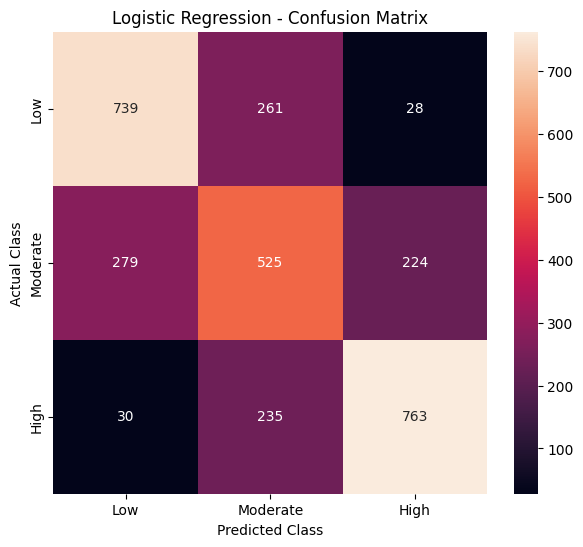

In [26]:
# ============================================================
# CELL 24: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1, 2]
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual_Low",
        "Actual_Moderate",
        "Actual_High"
    ],
    columns=[
        "Predicted_Low",
        "Predicted_Moderate",
        "Predicted_High"
    ]
)

display(cm_df)


plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Low",
        "Moderate",
        "High"
    ],
    yticklabels=[
        "Low",
        "Moderate",
        "High"
    ]
)

plt.title(
    "Logistic Regression - Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.show()

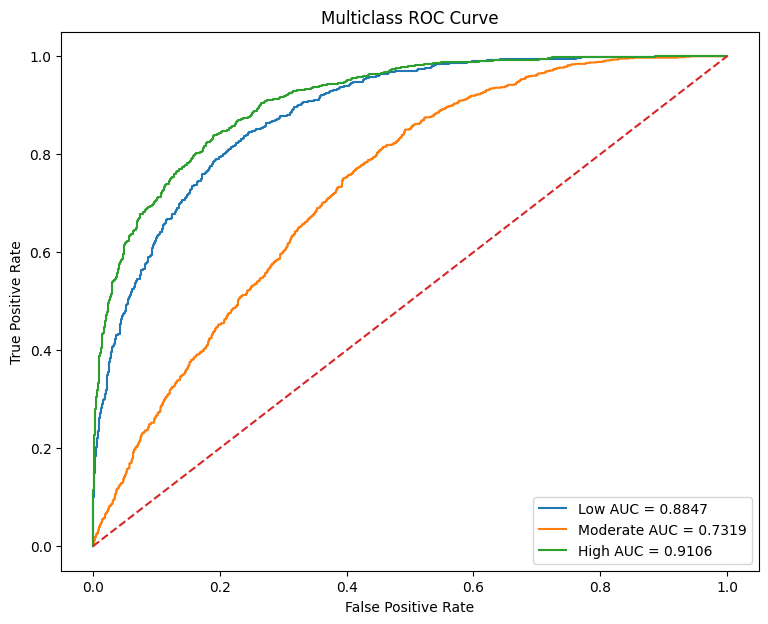

Macro ROC-AUC: 0.8424


In [27]:
# ============================================================
# CELL 25: MULTICLASS ROC CURVE
# ============================================================

from sklearn.preprocessing import label_binarize

y_test_binary = label_binarize(
    y_test,
    classes=[0, 1, 2]
)


plt.figure(figsize=(9, 7))


for i, class_name in enumerate(
    ["Low", "Moderate", "High"]
):

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        y_proba[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{class_name} "
            f"AUC = {class_auc:.4f}"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Multiclass ROC Curve"
)

plt.legend()

plt.show()

print(
    f"Macro ROC-AUC: {roc_auc:.4f}"
)

In [28]:
# ============================================================
# CELL 26: 50-EPOCH TRAINING HISTORY
# ============================================================

epoch_history_df = pd.DataFrame(
    epoch_history
)

display(
    epoch_history_df
)

,Epoch,Average_Loss,Training_Accuracy,Epoch_Time_Seconds,Epoch_Time_Minutes
0,1,0.871202,0.624676,0.041165,0.000686
1,2,0.774914,0.642267,0.032617,0.000544
2,3,0.750363,0.649887,0.032802,0.000547
3,4,0.737983,0.652399,0.031159,0.000519
4,5,0.729557,0.654507,0.031251,0.000521
5,6,0.724067,0.656858,0.032793,0.000547
6,7,0.719952,0.659047,0.031962,0.000533
7,8,0.716635,0.661479,0.032038,0.000534
8,9,0.714156,0.663911,0.030541,0.000509
9,10,0.711601,0.665289,0.031172,0.000520


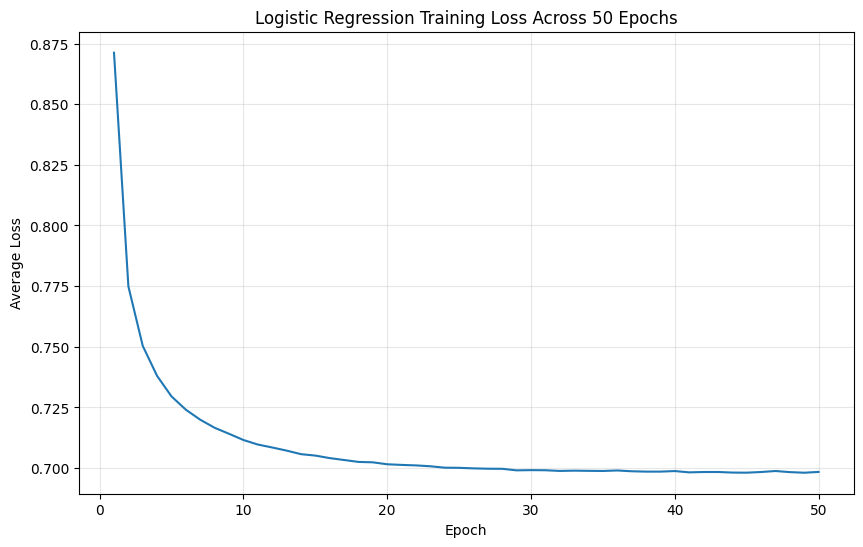

In [29]:
# ============================================================
# CELL 27: TRAINING LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epoch_history_df["Epoch"],
    epoch_history_df["Average_Loss"]
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Average Loss"
)

plt.title(
    "Logistic Regression Training Loss Across 50 Epochs"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

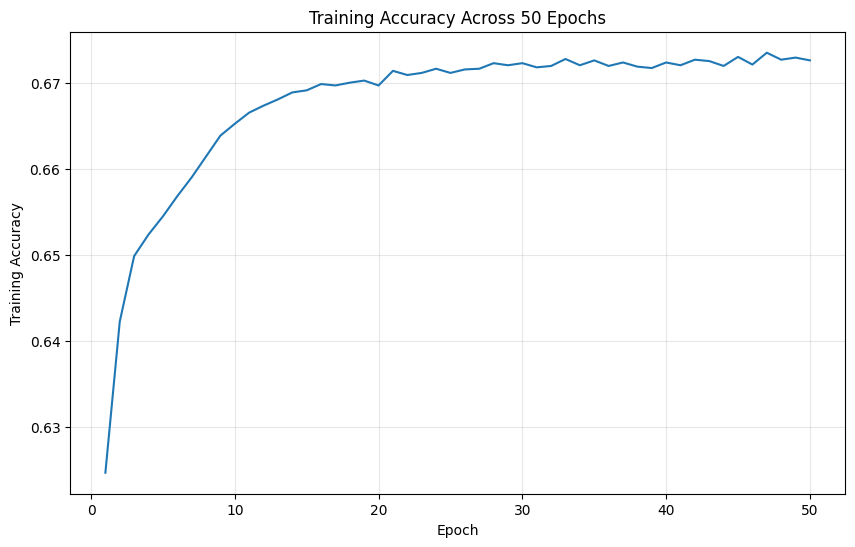

In [30]:
# ============================================================
# CELL 28: TRAINING ACCURACY VS EPOCH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epoch_history_df["Epoch"],
    epoch_history_df["Training_Accuracy"]
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Accuracy"
)

plt.title(
    "Training Accuracy Across 50 Epochs"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

In [31]:
# ============================================================
# CELL 29: LOGISTIC REGRESSION COEFFICIENT XAI
# ============================================================

coefficient_df = pd.DataFrame(
    weights,
    index=FEATURES,
    columns=[
        "Low",
        "Moderate",
        "High"
    ]
)

print(
    "Logistic Regression Coefficients:"
)

display(
    coefficient_df
)

Logistic Regression Coefficients:


,Low,Moderate,High
training_duration,0.291920,0.020302,-0.312222
training_intensity,-0.158322,0.083945,0.074378
training_load,-2.091970,0.015465,2.076504
heart_rate,0.023610,-0.015696,-0.007914
sleep_quality,0.004472,0.008151,-0.012623
recovery_score,0.424842,0.075587,-0.500429
stress_level,0.184018,0.053122,-0.237140


In [32]:
# ============================================================
# CELL 30: GLOBAL COEFFICIENT IMPORTANCE
# ============================================================

global_coefficient_importance = np.mean(
    np.abs(weights),
    axis=1
)

coefficient_importance_df = pd.DataFrame({

    "Feature": FEATURES,

    "Mean_Absolute_Coefficient":
        global_coefficient_importance

})

coefficient_importance_df = (
    coefficient_importance_df
    .sort_values(
        "Mean_Absolute_Coefficient",
        ascending=False
    )
)

display(
    coefficient_importance_df
)

,Feature,Mean_Absolute_Coefficient
2,training_load,1.394646
5,recovery_score,0.333620
0,training_duration,0.208148
6,stress_level,0.158093
1,training_intensity,0.105548
3,heart_rate,0.015740
4,sleep_quality,0.008415


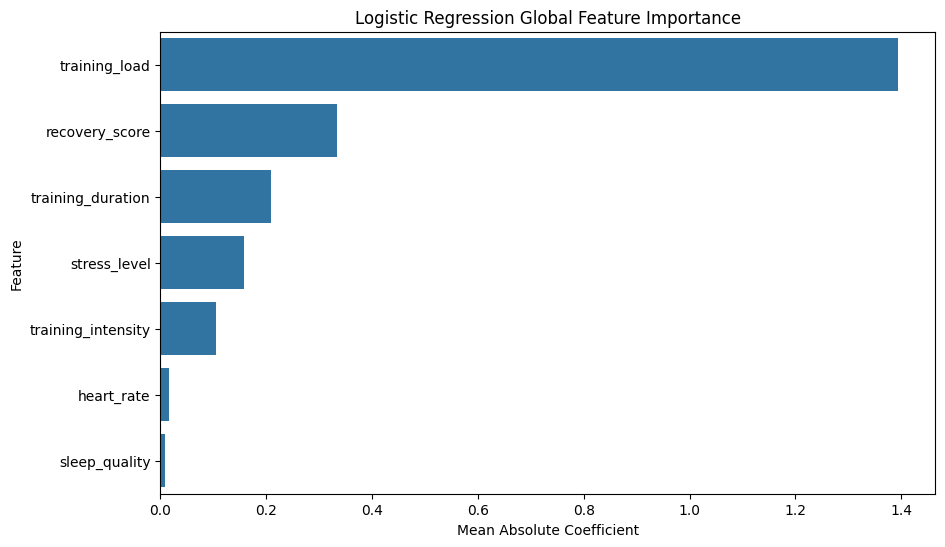

In [33]:
# ============================================================
# CELL 31: COEFFICIENT IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficient_importance_df,
    x="Mean_Absolute_Coefficient",
    y="Feature"
)

plt.title(
    "Logistic Regression Global Feature Importance"
)

plt.xlabel(
    "Mean Absolute Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [34]:
# ============================================================
# CELL 32: PERMUTATION IMPORTANCE
# ============================================================

permutation_start = time.perf_counter()


baseline_predictions = predict_manual(
    X_test_scaled
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="macro",
    zero_division=0
)


permutation_results = []

random_generator = np.random.RandomState(
    42
)

N_REPEATS = 10


for feature_index, feature_name in enumerate(
    FEATURES
):

    importance_values = []


    for repeat in range(
        N_REPEATS
    ):

        X_permuted = X_test_scaled.copy()


        random_generator.shuffle(
            X_permuted[:, feature_index]
        )


        permuted_predictions = predict_manual(
            X_permuted
        )


        permuted_f1 = f1_score(
            y_test,
            permuted_predictions,
            average="macro",
            zero_division=0
        )


        importance = (
            baseline_f1 -
            permuted_f1
        )


        importance_values.append(
            importance
        )


    permutation_results.append({

        "Feature": feature_name,

        "Importance_Mean":
            np.mean(
                importance_values
            ),

        "Importance_Std":
            np.std(
                importance_values
            )

    })


permutation_end = time.perf_counter()

permutation_time = (
    permutation_end -
    permutation_start
)


permutation_df = pd.DataFrame(
    permutation_results
)


permutation_df = (
    permutation_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
)


display(
    permutation_df
)

print(
    f"Permutation Importance Time: "
    f"{permutation_time:.6f} seconds"
)

,Feature,Importance_Mean,Importance_Std
2,training_load,0.313818,0.008467
5,recovery_score,0.028323,0.003934
0,training_duration,0.010172,0.003057
6,stress_level,0.003942,0.002592
3,heart_rate,0.001649,0.001359
1,training_intensity,0.000218,0.002465
4,sleep_quality,-0.001957,0.000960


Permutation Importance Time: 0.202302 seconds


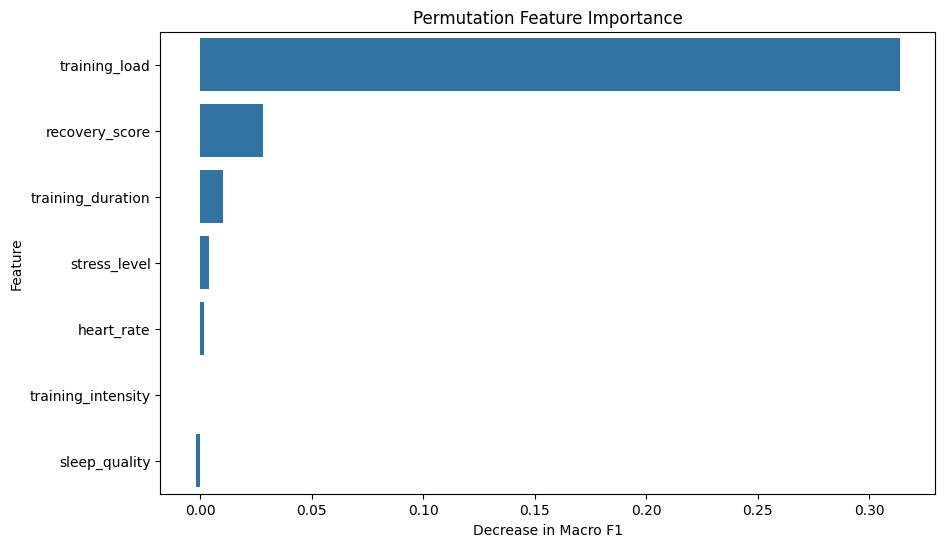

In [35]:
# ============================================================
# CELL 33: PERMUTATION IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=permutation_df,
    x="Importance_Mean",
    y="Feature"
)

plt.title(
    "Permutation Feature Importance"
)

plt.xlabel(
    "Decrease in Macro F1"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [36]:
# ============================================================
# CELL 34: INSTALL AND IMPORT SHAP
# ============================================================

!pip install -q shap

import shap

print(
    "SHAP version:",
    shap.__version__
)

SHAP version: 0.52.0


In [37]:
# ============================================================
# CELL 35: SHAP EXPLAINABILITY
# ============================================================

shap_start = time.perf_counter()


# Use a small background sample
background_size = min(
    100,
    len(X_train_scaled)
)

explanation_size = min(
    200,
    len(X_test_scaled)
)


background_data = X_train_scaled[
    :background_size
]

explanation_data = X_test_scaled[
    :explanation_size
]


# Create SHAP explainer
explainer = shap.Explainer(
    predict_proba_manual,
    background_data,
    feature_names=FEATURES
)


shap_explanation = explainer(
    explanation_data
)


shap_end = time.perf_counter()


shap_time = (
    shap_end -
    shap_start
)


print(
    "SHAP explanation generated successfully."
)

print(
    f"SHAP Wall Time: "
    f"{shap_time:.6f} seconds"
)

SHAP explanation generated successfully.
SHAP Wall Time: 6.684468 seconds


SHAP array shape: (200, 7, 3)


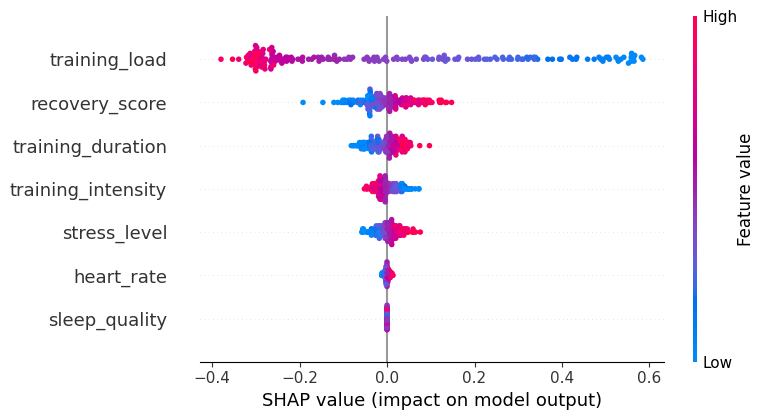

In [38]:
# ============================================================
# CELL 36: SHAP SUMMARY - LOW FATIGUE
# ============================================================

shap_values_array = (
    shap_explanation.values
)

print(
    "SHAP array shape:",
    shap_values_array.shape
)


# Class 0 = Low
shap.summary_plot(
    shap_values_array[:, :, 0],
    explanation_data,
    feature_names=FEATURES
)

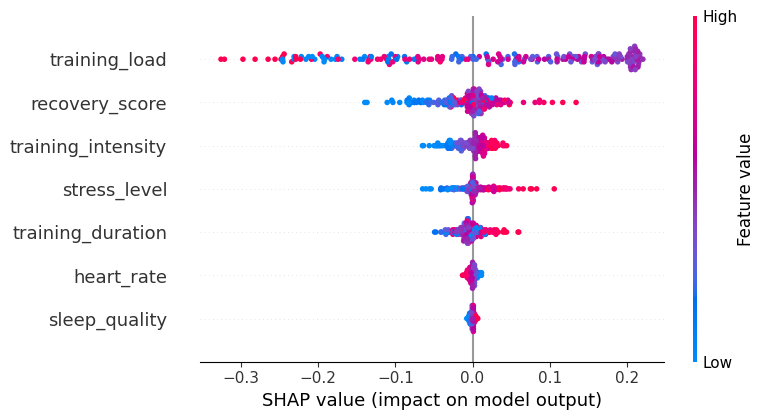

In [39]:
# ============================================================
# CELL 37: SHAP SUMMARY - MODERATE FATIGUE
# ============================================================

shap.summary_plot(
    shap_values_array[:, :, 1],
    explanation_data,
    feature_names=FEATURES
)

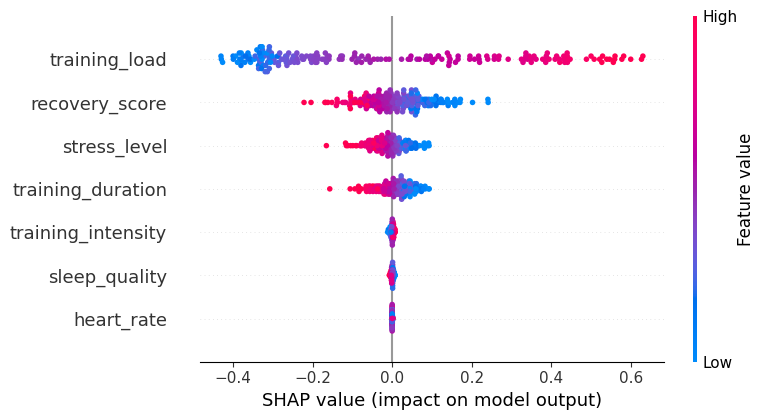

In [40]:
# ============================================================
# CELL 38: SHAP SUMMARY - HIGH FATIGUE
# ============================================================

shap.summary_plot(
    shap_values_array[:, :, 2],
    explanation_data,
    feature_names=FEATURES
)

In [41]:
# ============================================================
# CELL 39: GLOBAL SHAP IMPORTANCE
# ============================================================

mean_absolute_shap = np.mean(
    np.abs(
        shap_values_array
    ),
    axis=(0, 2)
)


shap_importance_df = pd.DataFrame({

    "Feature": FEATURES,

    "Mean_Absolute_SHAP":
        mean_absolute_shap

})


shap_importance_df = (
    shap_importance_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
)


display(
    shap_importance_df
)

,Feature,Mean_Absolute_SHAP
2,training_load,0.225139
5,recovery_score,0.045594
0,training_duration,0.024137
6,stress_level,0.023000
1,training_intensity,0.013053
3,heart_rate,0.002455
4,sleep_quality,0.001335


In [42]:
# ============================================================
# CELL 40: INDIVIDUAL PREDICTION EXPLANATION
# ============================================================

sample_index = 0

sample = X_test.iloc[
    [sample_index]
]


sample_scaled = X_test_scaled[
    sample_index:
    sample_index + 1
]


sample_prediction = predict_manual(
    sample_scaled
)[0]


sample_probabilities = predict_proba_manual(
    sample_scaled
)[0]


print("=" * 60)

print("INDIVIDUAL PREDICTION")

print("=" * 60)


print(
    "\nActual Class:"
)

print(
    reverse_mapping[
        int(y_test.iloc[sample_index])
    ]
)


print(
    "\nPredicted Class:"
)

print(
    reverse_mapping[
        int(sample_prediction)
    ]
)


print(
    "\nPrediction Probabilities:"
)

for class_id, probability in enumerate(
    sample_probabilities
):

    print(
        f"{reverse_mapping[class_id]}: "
        f"{probability:.4f}"
    )


print(
    "\nInput Values:"
)

display(
    sample
)

INDIVIDUAL PREDICTION

Actual Class:
High

Predicted Class:
High

Prediction Probabilities:
Low: 0.0008
Moderate: 0.0557
High: 0.9435

Input Values:


,training_duration,training_intensity,training_load,heart_rate,sleep_quality,recovery_score,stress_level
12241,86.881805,6.63742,1065.304776,54.157744,5.232316,34.04027,0.200896


In [43]:
# ============================================================
# CELL 41: INDIVIDUAL COEFFICIENT CONTRIBUTION
# ============================================================

predicted_class = int(
    sample_prediction
)


sample_contributions = (
    weights[:, predicted_class]
    *
    sample_scaled[0]
)


individual_explanation_df = pd.DataFrame({

    "Feature": FEATURES,

    "Standardized_Value":
        sample_scaled[0],

    "Coefficient":
        weights[:, predicted_class],

    "Contribution":
        sample_contributions,

    "Absolute_Contribution":
        np.abs(
            sample_contributions
        )

})


individual_explanation_df = (
    individual_explanation_df
    .sort_values(
        "Absolute_Contribution",
        ascending=False
    )
)


print(
    "Prediction explanation for:",
    reverse_mapping[predicted_class]
)

display(
    individual_explanation_df
)

Prediction explanation for: High


,Feature,Standardized_Value,Coefficient,Contribution,Absolute_Contribution
2,training_load,1.196499,2.076504,2.484536,2.484536
5,recovery_score,-1.218762,-0.500429,0.609904,0.609904
6,stress_level,-1.277944,-0.237140,0.303052,0.303052
1,training_intensity,0.141249,0.074378,0.010506,0.010506
0,training_duration,-0.030250,-0.312222,0.009445,0.009445
3,heart_rate,-1.045707,-0.007914,0.008276,0.008276
4,sleep_quality,-0.330732,-0.012623,0.004175,0.004175


In [45]:
# ============================================================
# CELL 42: WHAT-IF ANALYSIS FUNCTION
# ============================================================

def what_if_prediction(
    sample_row,
    sleep_quality=None,
    recovery_score=None,
    stress_level=None
):

    modified = sample_row.copy()


    if sleep_quality is not None:

        modified[
            "sleep_quality"
        ] = sleep_quality


    if recovery_score is not None:

        modified[
            "recovery_score"
        ] = recovery_score


    if stress_level is not None:

        modified[
            "stress_level"
        ] = stress_level


    modified_imputed = imputer.transform(
        modified
    )

    modified_scaled = scaler.transform(
        modified_imputed
    )


    prediction = predict_manual(
        modified_scaled
    )[0]


    probabilities = predict_proba_manual(
        modified_scaled
    )[0]


    return pd.Series({

        "Predicted_Class":
            reverse_mapping[
                int(prediction)
            ],

        "Low_Probability":
            probabilities[0],

        "Moderate_Probability":
            probabilities[1],

        "High_Probability":
            probabilities[2]

    })

In [46]:
# ============================================================
# CELL 43: WHAT-IF EXAMPLE
# ============================================================

original_result = what_if_prediction(
    sample
)


better_recovery_result = what_if_prediction(
    sample,
    sleep_quality=8,
    recovery_score=85,
    stress_level=0.20
)


print("ORIGINAL PREDICTION")

display(
    original_result.to_frame(
        "Original"
    )
)


print(
    "\nWHAT-IF PREDICTION"
)

display(
    better_recovery_result.to_frame(
        "What-if"
    )
)

ORIGINAL PREDICTION


,Original
Predicted_Class,High
Low_Probability,0.000794
Moderate_Probability,0.055665
High_Probability,0.943541



WHAT-IF PREDICTION


,What-if
Predicted_Class,High
Low_Probability,0.009759
Moderate_Probability,0.246428
High_Probability,0.743813


In [47]:
# ============================================================
# CELL 44: SAVE 50-EPOCH HISTORY
# ============================================================

epoch_history_path = (
    "/kaggle/working/"
    "logistic_regression_50_epoch_history.csv"
)


epoch_history_df.to_csv(
    epoch_history_path,
    index=False
)


print(
    "Epoch history saved:"
)

print(
    epoch_history_path
)

Epoch history saved:
/kaggle/working/logistic_regression_50_epoch_history.csv


In [48]:
# ============================================================
# CELL 45: SAVE EVALUATION METRICS
# ============================================================

metrics_df = pd.DataFrame({

    "Metric": [

        "Training Accuracy",
        "Testing Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
        "Precision Weighted",
        "Recall Weighted",
        "F1 Weighted",
        "ROC AUC Macro OVR",
        "Number of Epochs"

    ],

    "Value": [

        train_accuracy,
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        roc_auc,
        EPOCHS

    ]

})


metrics_path = (
    "/kaggle/working/"
    "logistic_regression_metrics.csv"
)


metrics_df.to_csv(
    metrics_path,
    index=False
)


display(
    metrics_df
)

print(
    "\nSaved:",
    metrics_path
)

,Metric,Value
0,Training Accuracy,0.672665
1,Testing Accuracy,0.657263
2,Precision Macro,0.657026
3,Recall Macro,0.657263
4,F1 Macro,0.657111
5,Precision Weighted,0.657026
6,Recall Weighted,0.657263
7,F1 Weighted,0.657111
8,ROC AUC Macro OVR,0.842374
9,Number of Epochs,50.000000



Saved: /kaggle/working/logistic_regression_metrics.csv


In [49]:
# ============================================================
# CELL 46: SAVE WALL TIME
# ============================================================

total_training_time = training_time

wall_time_df = pd.DataFrame({

    "Operation": [

        "Training",
        "Prediction",
        "Permutation Importance",
        "SHAP"

    ],

    "Wall_Time_Seconds": [

        total_training_time,
        prediction_time,
        permutation_time,
        shap_time

    ],

    "Wall_Time_Minutes": [

        total_training_time / 60,
        prediction_time / 60,
        permutation_time / 60,
        shap_time / 60

    ]

})


wall_time_path = (
    "/kaggle/working/"
    "logistic_regression_wall_time.csv"
)


wall_time_df.to_csv(
    wall_time_path,
    index=False
)


display(
    wall_time_df
)


print(
    "Saved:",
    wall_time_path
)

,Operation,Wall_Time_Seconds,Wall_Time_Minutes
0,Training,1.674774,0.027913
1,Prediction,0.002737,0.000046
2,Permutation Importance,0.202302,0.003372
3,SHAP,6.684468,0.111408


Saved: /kaggle/working/logistic_regression_wall_time.csv


In [50]:
# ============================================================
# CELL 47: SAVE PREDICTIONS
# ============================================================

prediction_results = X_test.copy()


prediction_results[
    "Actual_Class"
] = [
    reverse_mapping[int(value)]
    for value in y_test
]


prediction_results[
    "Predicted_Class"
] = [
    reverse_mapping[int(value)]
    for value in y_pred
]


prediction_results[
    "Probability_Low"
] = y_proba[:, 0]


prediction_results[
    "Probability_Moderate"
] = y_proba[:, 1]


prediction_results[
    "Probability_High"
] = y_proba[:, 2]


prediction_path = (
    "/kaggle/working/"
    "logistic_regression_predictions.csv"
)


prediction_results.to_csv(
    prediction_path,
    index=False
)


print(
    "Saved:",
    prediction_path
)

display(
    prediction_results.head()
)

Saved: /kaggle/working/logistic_regression_predictions.csv


,training_duration,training_intensity,training_load,heart_rate,sleep_quality,recovery_score,stress_level,Actual_Class,Predicted_Class,Probability_Low,Probability_Moderate,Probability_High
12241,86.881805,6.637420,1065.304776,54.157744,5.232316,34.040270,0.200896,High,High,0.000794,0.055665,0.943541
8250,76.660238,4.379396,252.184518,75.385134,4.874612,50.030975,0.583437,Low,Low,0.856423,0.138325,0.005252
7492,101.735520,6.429898,683.864889,72.455938,7.504503,66.156031,0.538278,Low,Moderate,0.284136,0.572155,0.143709
2795,104.794615,7.335382,1139.497749,93.701874,6.672660,41.906061,0.346497,High,High,0.000971,0.071107,0.927921
3971,69.294073,5.979479,450.352913,54.992754,5.528568,55.832269,0.360705,Low,Low,0.501050,0.427558,0.071392


In [51]:
# ============================================================
# CELL 48: SAVE XAI RESULTS
# ============================================================

coefficient_path = (
    "/kaggle/working/"
    "logistic_regression_coefficient_importance.csv"
)

coefficient_importance_df.to_csv(
    coefficient_path,
    index=False
)


permutation_path = (
    "/kaggle/working/"
    "logistic_regression_permutation_importance.csv"
)

permutation_df.to_csv(
    permutation_path,
    index=False
)


shap_path = (
    "/kaggle/working/"
    "logistic_regression_shap_importance.csv"
)

shap_importance_df.to_csv(
    shap_path,
    index=False
)


individual_path = (
    "/kaggle/working/"
    "logistic_regression_individual_explanation.csv"
)

individual_explanation_df.to_csv(
    individual_path,
    index=False
)


print("XAI files saved successfully.")

print(
    "\n1.",
    coefficient_path
)

print(
    "2.",
    permutation_path
)

print(
    "3.",
    shap_path
)

print(
    "4.",
    individual_path
)

XAI files saved successfully.

1. /kaggle/working/logistic_regression_coefficient_importance.csv
2. /kaggle/working/logistic_regression_permutation_importance.csv
3. /kaggle/working/logistic_regression_shap_importance.csv
4. /kaggle/working/logistic_regression_individual_explanation.csv


In [52]:
# ============================================================
# CELL 49: SAVE CONFUSION MATRIX
# ============================================================

confusion_path = (
    "/kaggle/working/"
    "logistic_regression_confusion_matrix.csv"
)


cm_df.to_csv(
    confusion_path
)


print(
    "Confusion matrix saved:"
)

print(
    confusion_path
)

Confusion matrix saved:
/kaggle/working/logistic_regression_confusion_matrix.csv


In [53]:
# ============================================================
# CELL 50: SAVE TRAINED MODEL
# ============================================================

model_package = {

    "weights": weights,

    "bias": bias,

    "imputer": imputer,

    "scaler": scaler,

    "features": FEATURES,

    "target": TARGET,

    "class_mapping": class_mapping,

    "reverse_mapping": reverse_mapping,

    "fatigue_q1": float(q1),

    "fatigue_q2": float(q2),

    "epochs": EPOCHS,

    "batch_size": BATCH_SIZE,

    "learning_rate": LEARNING_RATE,

    "model": "Multiclass Logistic Regression",

    "training_method":
        "Mini-Batch Gradient Descent"

}


model_path = (
    "/kaggle/working/"
    "logistic_regression_fatigue_model.joblib"
)


joblib.dump(
    model_package,
    model_path
)


print(
    "Trained model saved successfully:"
)

print(
    model_path
)

Trained model saved successfully:
/kaggle/working/logistic_regression_fatigue_model.joblib


In [54]:
# ============================================================
# CELL 51: FINAL MODEL SUMMARY
# ============================================================

print("=" * 70)

print(
    "ATHLETE FATIGUE PREDICTION"
)

print(
    "LOGISTIC REGRESSION MODEL"
)

print("=" * 70)


print("\nFEATURES USED:")

for feature in FEATURES:

    print(
        "✓",
        feature
    )


print("\nIDENTIFIERS IGNORED:")

print("✓ athlete_id")
print("✓ session_id")


print("\nTARGET:")

print(
    "fatigue_index"
)

print(
    "→ Low / Moderate / High"
)


print("\nMODEL:")

print(
    "Multiclass Logistic Regression"
)


print("\nTRAINING:")

print(
    f"Epochs       : {EPOCHS}"
)

print(
    f"Batch Size   : {BATCH_SIZE}"
)

print(
    f"Learning Rate: {LEARNING_RATE}"
)


print("\nEVALUATION:")

print(
    f"Accuracy      : {accuracy:.4f}"
)

print(
    f"Precision      : {precision_macro:.4f}"
)

print(
    f"Recall         : {recall_macro:.4f}"
)

print(
    f"F1 Score       : {f1_macro:.4f}"
)

print(
    f"ROC-AUC        : {roc_auc:.4f}"
)


print("\nWALL TIME:")

print(
    f"Training       : "
    f"{training_time:.6f} sec"
)

print(
    f"Prediction     : "
    f"{prediction_time:.6f} sec"
)

print(
    f"Permutation XAI: "
    f"{permutation_time:.6f} sec"
)

print(
    f"SHAP           : "
    f"{shap_time:.6f} sec"
)


print("\nXAI METHODS:")

print("✓ Logistic Regression Coefficients")
print("✓ Permutation Importance")
print("✓ SHAP")
print("✓ Individual Prediction Explanation")
print("✓ What-If Analysis")


print("\n" + "=" * 70)

print(
    "TRAINING, EVALUATION AND XAI COMPLETED"
)

print("=" * 70)

ATHLETE FATIGUE PREDICTION
LOGISTIC REGRESSION MODEL

FEATURES USED:
✓ training_duration
✓ training_intensity
✓ training_load
✓ heart_rate
✓ sleep_quality
✓ recovery_score
✓ stress_level

IDENTIFIERS IGNORED:
✓ athlete_id
✓ session_id

TARGET:
fatigue_index
→ Low / Moderate / High

MODEL:
Multiclass Logistic Regression

TRAINING:
Epochs       : 50
Batch Size   : 32
Learning Rate: 0.01

EVALUATION:
Accuracy      : 0.6573
Precision      : 0.6570
Recall         : 0.6573
F1 Score       : 0.6571
ROC-AUC        : 0.8424

WALL TIME:
Training       : 1.674774 sec
Prediction     : 0.002737 sec
Permutation XAI: 0.202302 sec
SHAP           : 6.684468 sec

XAI METHODS:
✓ Logistic Regression Coefficients
✓ Permutation Importance
✓ SHAP
✓ Individual Prediction Explanation
✓ What-If Analysis

TRAINING, EVALUATION AND XAI COMPLETED
